In [1]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.metrics import(
    mean_squared_error,
    r2_score,
    root_mean_squared_error
)

In [2]:
class RidgeRegression:

    def __init__(self, learning_rate=0.01, epochs=1000, alpha=1.0):

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha

        self.weights = None
        self.bias = None

        self.loss_history = []

    def fit(self, X_train, y_train):

        n_samples, n_features = X_train.shape

        self.w = np.zeros(n_features)
        self.b = 0

        loss_history = []

        for _ in range(self.epochs):

            y_hat = self.predict(X_train)

            error = y_hat - y_train

            dw = (
                    (2 / n_samples) * (X_train.T @ error)
                    + (2 * self.alpha / n_samples) * self.w
            )

            db = (2 / n_samples) * np.sum(error)

            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            mse = np.mean(error ** 2)
            l2_penalty = (self.alpha / n_samples) * np.sum(self.w ** 2)

            loss = mse + l2_penalty

            loss_history.append(loss)

        self.loss_history = loss_history

    def predict(self, X):
        return X @ self.w + self.b


In [3]:
df_raw = load_diabetes(as_frame=True)
df = df_raw.frame

df.head(10)

X = df.drop('target' , axis = 1)
y = df['target']

X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    shuffle=True,
    random_state=42,
    test_size=0.2
)

scaler = StandardScaler(with_std=True , with_mean=True)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RidgeRegression(
    learning_rate=0.1,
    epochs=1000,
    alpha = 0.01,
)

model.fit(X_train , y_train)

print("Weights :", model.w)
print("Bias :", model.b)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE :", rmse)
print("R² :", r2)


Weights : [  1.78980749 -11.49749159  25.73386602  16.78753962 -37.83080044
  19.4647674    4.7574019   12.22953416  32.62123912   2.39964823]
Bias : 153.7365439093484
MSE : 2895.244164483258
RMSE : 53.80747312858371
R² : 0.45353694988183757


# **Visualization**

# Visualization 1 — L1 Penalty Function

## Objective

The first visualization helps us understand **what Lasso actually penalizes**.

Unlike Ridge Regression, which penalizes the **square of the weights**, Lasso penalizes the **absolute value of the weights**.

Mathematically,

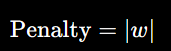

where (w) is a model coefficient (weight).

---

## Why do we plot this?

Lasso's feature selection ability comes entirely from the shape of this graph.

Understanding this graph explains why Lasso can make coefficients exactly zero.

---

## What will we observe?

The graph has a **V-shape**.

* The minimum penalty occurs at

`**w=0**`

* As the weight moves away from zero in either direction, the penalty increases **linearly**.

Unlike Ridge, the graph has a **sharp corner** at zero.

---

## Interpretation

Suppose

```text
Weight = 0
Penalty = 0
```

No penalty is added.

---

Suppose

```text
Weight = 3
Penalty = 3
```

---

Suppose

```text
Weight = -3
Penalty = 3
```

Notice that

```text
+3 and -3 receive exactly the same penalty.
```

because Lasso uses the **absolute value**.

---

Now observe the point

```text
w = 0
```

The graph has a **sharp corner** instead of being smooth.

This is the key reason Lasso behaves differently from Ridge.

At this corner:

* the derivative is **not defined**,
* optimization uses a **subgradient**,
* coefficients are easily pushed to **exactly zero**.

This is why Lasso performs **automatic feature selection**.

---

## Key Takeaways

* Lasso penalizes the **absolute value** of coefficients.
* The penalty increases **linearly**.
* Positive and negative coefficients are penalized equally.
* The sharp corner at **0** is what allows Lasso to eliminate features.

---
---

## Expected Graph

You should see a **V-shaped graph**:

```text
Penalty
 ^
 |
5|         /
4|        /
3|       /
2|      /
1|     /
0|____/ \____> Weight
     0
```

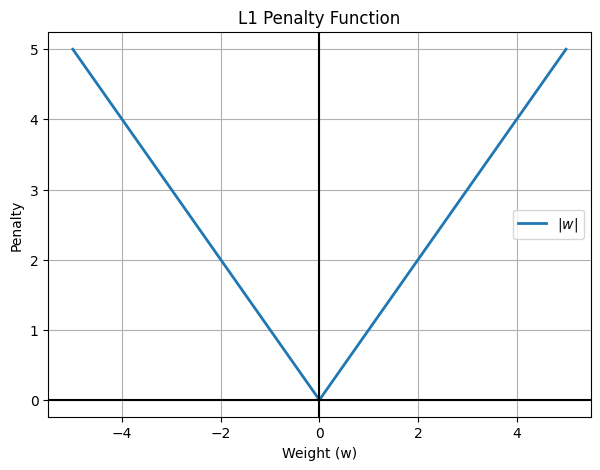

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Weight values
w = np.linspace(-5, 5, 500)

# L1 Penalty
penalty = np.abs(w)

plt.figure(figsize=(7,5))

plt.plot(
    w,
    penalty,
    linewidth=2,
    label=r"$|w|$"
)

# X and Y axes
plt.axhline(0, color="black")
plt.axvline(0, color="black")

plt.xlabel("Weight (w)")
plt.ylabel("Penalty")

plt.title("L1 Penalty Function")

plt.legend()

plt.grid(True)

plt.show()

# Visualization 2 — Ridge vs Lasso Penalty Comparison

## Objective

In the previous visualization, we saw how **Lasso penalizes the absolute value of the coefficients**.

Now we'll compare **Lasso (L1)** and **Ridge (L2)** on the same graph.

This visualization helps answer one of the most important questions:

> **Why does Ridge only shrink coefficients, while Lasso can make them exactly zero?**

---

## Mathematical Functions

### Ridge (L2)

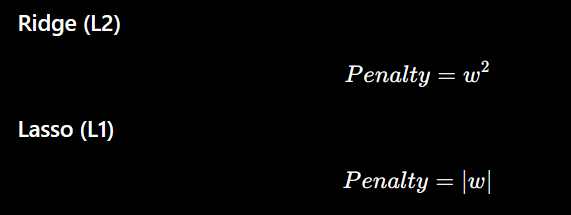
---

## Why compare them?

Both algorithms add a penalty to the loss function.

The only difference is **how that penalty grows**.

Ridge:

* Uses squares.
* Produces a smooth parabola.

Lasso:

* Uses absolute values.
* Produces a V-shaped graph.

Although this looks like a small mathematical change, it completely changes how the optimization behaves.

---

## What will we observe?

### Ridge Curve

* Smooth everywhere.
* Curved parabola.
* Slope gradually decreases near zero.

---

### Lasso Curve

* V-shaped.
* Sharp corner at zero.
* Constant slope on each side.

---

## Interpretation

Suppose

```text
Weight = 5
```

### Ridge Penalty

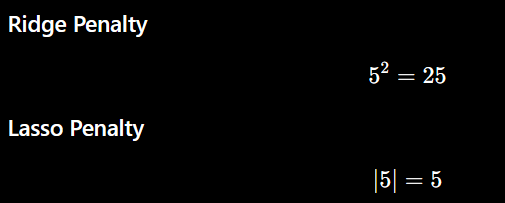

Ridge penalizes large coefficients **much more aggressively** because the penalty grows quadratically.

Lasso penalizes them **linearly**.

---

Now consider a very small weight.

```text
Weight = 0.1
```

### Ridge

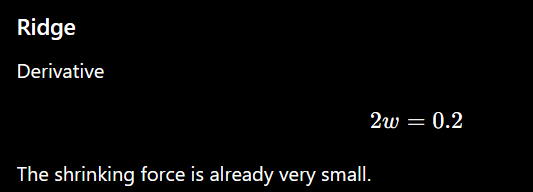

---

### Lasso

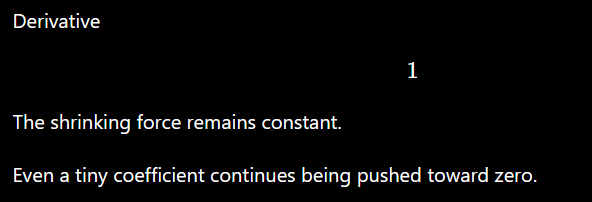

---

## Why is this important?

Imagine Gradient Descent.

### Ridge

```text
5

↓

2

↓

1

↓

0.5

↓

0.2

↓

0.05

↓

0.001

↓

Almost never exactly zero
```

As the coefficient gets smaller, the gradient becomes smaller.

Eventually the updates become tiny.

---

### Lasso

```text
5

↓

4

↓

3

↓

2

↓

1

↓

0

Feature removed
```

The shrinking force remains almost constant.

The coefficient reaches zero much more easily.

---

## Key Takeaways

* Ridge uses **quadratic growth**.
* Lasso uses **linear growth**.
* Ridge has a **smooth** curve.
* Lasso has a **sharp corner**.
* The sharp corner explains why Lasso performs **feature selection**.

---
---

## Expected Graph

```text
Penalty
 ^
 |
 |                    Ridge
 |                  /
 |                /
 |              /
 |            /
 |          /
 |         /
 |        /
 |       /
 |      /
 |_____/__________> Weight
 |    /\
 |   /  \
 |  /    \
 | /      \
 |/
Lasso
```

* The **curved parabola** represents Ridge.
* The **V-shaped line** represents Lasso.

---

## Conclusion

This graph explains the **core behavioral difference** between Ridge and Lasso:

* **Ridge** applies a shrinking force that weakens as the coefficient approaches zero, so coefficients become small but usually remain nonzero.
* **Lasso** applies a nearly constant shrinking force until the coefficient reaches zero, allowing it to eliminate unimportant features automatically.

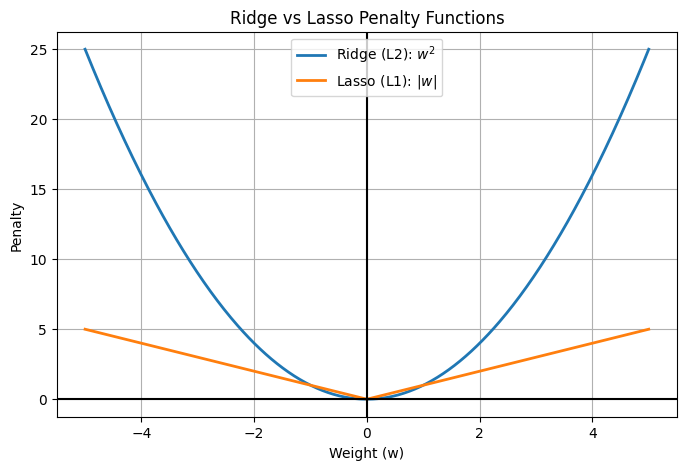

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Weight values
w = np.linspace(-5, 5, 500)

# Penalty functions
ridge_penalty = w ** 2
lasso_penalty = np.abs(w)

plt.figure(figsize=(8,5))

plt.plot(
    w,
    ridge_penalty,
    linewidth=2,
    label="Ridge (L2): $w^2$"
)

plt.plot(
    w,
    lasso_penalty,
    linewidth=2,
    label="Lasso (L1): $|w|$"
)

plt.axhline(0, color="black")
plt.axvline(0, color="black")

plt.xlabel("Weight (w)")
plt.ylabel("Penalty")

plt.title("Ridge vs Lasso Penalty Functions")

plt.legend()

plt.grid(True)

plt.show()

# Visualization 3 — Coefficient Path (Most Important Visualization)

> ⭐ This is the **most important visualization** for understanding Lasso Regression.

---

# Objective

The goal of this visualization is to observe **how every coefficient changes as the regularization strength (α) changes**.

Instead of looking at only one trained model, we train **many Lasso models**, each with a different value of **α**, and record the coefficient of every feature.

---

# What is plotted?

### X-axis

```text
Alpha (Regularization Strength)
```

Usually plotted on a **logarithmic scale**.

---

### Y-axis

```text
Coefficient Value
```

---

### Each Line

Every colored line represents **one feature**.

Example:

```text
Blue Line   → Age
Orange Line → BMI
Green Line  → Blood Pressure
...
```

If your dataset has **10 features**, you will see **10 lines**.

---

# Why is this visualization useful?

Lasso performs **feature selection**.

This graph lets us literally watch features disappear as α increases.

Instead of reading coefficients in a table, we can **see** them shrinking.

---

# What happens when α is very small?

Suppose

```text
Alpha = 0.0001
```

The regularization is almost zero.

Lasso behaves very similarly to Linear Regression.

You will observe

```text
All coefficients have relatively large values.
```

Example

```text
Feature 1 : 45

Feature 2 : -30

Feature 3 : 18

Feature 4 : 12
```

Nearly every feature contributes to the model.

---

# What happens as α increases?

Now suppose

```text
Alpha = 0.1
```

Regularization becomes stronger.

Now the optimization starts shrinking coefficients.

Example

```text
45 → 30

18 → 10

12 → 4
```

Some coefficients decrease faster than others.

---

# What happens when α becomes large?

Suppose

```text
Alpha = 10
```

Now Lasso strongly penalizes coefficients.

Some become

```text
0
```

Others become

```text
Very close to zero
```

Eventually

```text
Feature 1 : 0

Feature 2 : 0

Feature 3 : 7

Feature 4 : 0
```

Only the most important features remain.

---

# What should you observe?

While looking at the graph, notice:

### 1. Every line moves toward zero.

All coefficients shrink.

---

### 2. Some lines hit zero much earlier.

These correspond to **less important features**.

Lasso removes them from the model.

---

### 3. Important features survive longer.

Their coefficients stay away from zero even for larger α.

These are the features that carry the most predictive information.

---

### 4. Eventually almost every coefficient becomes zero.

If α becomes extremely large,

the model predicts almost the same value for every sample because all feature weights vanish.

This is **underfitting**.

---

# Interpretation

Suppose your graph shows

```text
Feature A

↓

Touches zero very early
```

Interpretation

> Feature A contributes very little to prediction.

---

Suppose

```text
Feature B

↓

Still far from zero
```

Interpretation

> Feature B is important and Lasso keeps it.

---

# Key Takeaways

* Each line represents one feature.
* Increasing α increases regularization.
* Coefficients shrink toward zero.
* Some coefficients become exactly zero.
* Features whose coefficients become zero are automatically removed from the model.

This is why Lasso is often called a **feature selection algorithm**.

---
---

# Expected Graph

```text
Coefficient
^

40 |\
   | \
30 |  \
   |   \
20 |    \______
   |           \
10 |            \__
   |               \
 0 |-----------------------------> Alpha
      Small              Large
```

Each line gradually moves toward **0** as α increases.

Some lines touch **0** much earlier than others.

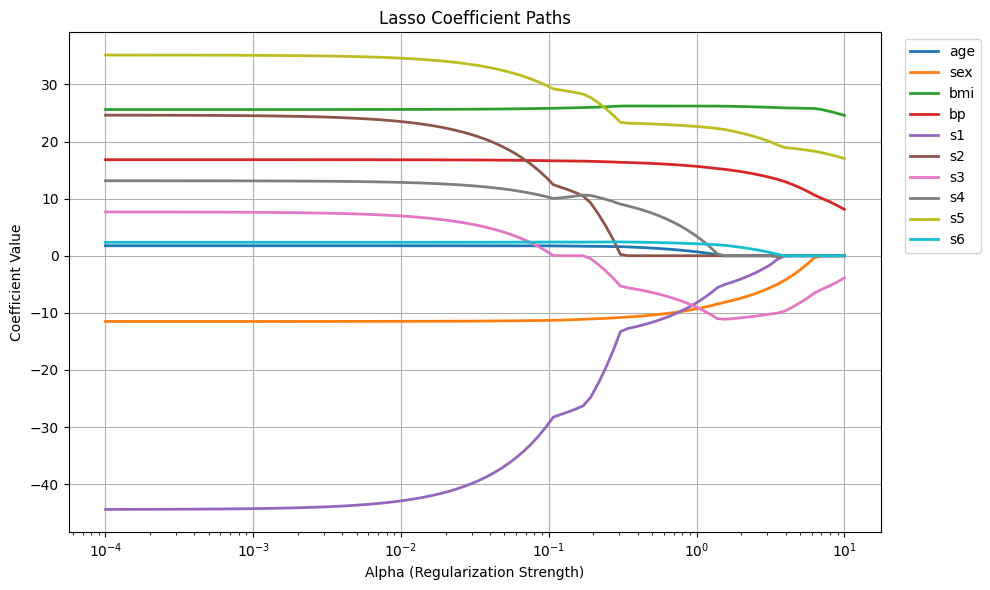

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

# Different alpha values
alphas = np.logspace(-4, 1, 100)

coefficients = []

# Train a model for each alpha
for alpha in alphas:

    model = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    model.fit(X_train, y_train)

    coefficients.append(model.coef_)

coefficients = np.array(coefficients)

# Plot coefficient paths
plt.figure(figsize=(10,6))

for i in range(coefficients.shape[1]):
    plt.plot(
        alphas,
        coefficients[:, i],
        linewidth=2,
        label=X.columns[i]
    )

plt.xscale("log")

# Small alpha on left, large alpha on right
# (More intuitive for observing shrinkage)
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Coefficient Value")

plt.title("Lasso Coefficient Paths")

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# Visualization 4 — Number of Zero Coefficients vs Alpha

This visualization is a natural continuation of the **Coefficient Path**.

Previously, we saw **which coefficients shrink to zero**.

Now we'll answer a different question:

> **As α increases, how many features are removed from the model?**

---

# Objective

Lasso performs **automatic feature selection**.

This graph measures the strength of that feature selection.

Instead of plotting coefficient values, we simply count

```text
Number of coefficients equal to zero
```

for different values of α.

---

# What is plotted?

### X-axis

```text
Alpha (Regularization Strength)
```

Small α

↓

Weak regularization

Large α

↓

Strong regularization

---

### Y-axis

```text
Number of Zero Coefficients
```

This tells us

> How many features Lasso has completely removed.

---

# What happens when α is very small?

Suppose

```text
Alpha = 0.0001
```

Almost no regularization.

Lasso behaves almost like Linear Regression.

Example

```text
Feature A : 22

Feature B : -10

Feature C : 18

Feature D : 5
```

No feature is removed.

So

```text
Zero Coefficients = 0
```

---

# What happens as α increases?

Now suppose

```text
Alpha = 0.1
```

Regularization becomes stronger.

Some coefficients become

```text
0
```

Example

```text
Feature A : 18

Feature B : 0

Feature C : 9

Feature D : 0
```

Now

```text
Zero Coefficients = 2
```

Two features have been removed.

---

# What happens when α becomes very large?

Suppose

```text
Alpha = 10
```

Now almost every coefficient becomes

```text
0
```

Example

```text
Feature A : 0

Feature B : 0

Feature C : 0

Feature D : 0
```

Now

```text
Zero Coefficients = 4
```

The model is becoming too simple.

This is called **underfitting**.

---

# What should you observe?

As α increases,

the graph should generally move upward.

Example

```text
Alpha          Zero Features

0.0001         0

0.001          0

0.01           1

0.1            3

1              6

10             10
```

This means

* Weak regularization → Almost every feature survives.
* Strong regularization → Many features are removed.

---

# Interpretation

Suppose your graph shows

```text
Alpha = 0.1

↓

3 features removed
```

Interpretation

> Lasso determined that these three features contribute very little to prediction.

---

Suppose

```text
Alpha = 1

↓

7 features removed
```

Interpretation

> The model has become much simpler by keeping only the most informative features.

---

Suppose

```text
Alpha = 100

↓

All features removed
```

Interpretation

> Regularization is too strong.
>
> The model has underfit the data.

---

# Key Takeaways

* Increasing α increases feature selection.
* More coefficients become exactly zero.
* Larger α produces a simpler model.
* Extremely large α can remove too many features, causing underfitting.

---
---

# Expected Graph

```text
Zero
Coefficients
^

10 |                           ●
 9 |                        ●
 8 |                     ●
 7 |                  ●
 6 |               ●
 5 |            ●
 4 |         ●
 3 |      ●
 2 |   ●
 1 | ●
 0 |_______________________________> Alpha
      Small                Large
```

---

# Relation with the Previous Graph

The **Coefficient Path** showed:

> **Which** features became zero.

This graph shows:

> **How many** features became zero.

Together, these two visualizations completely explain **Lasso's feature selection behavior**.

---

## Conclusion

This graph demonstrates the central idea of Lasso Regression:

> As the regularization strength (α) increases, more coefficients are driven to exactly zero, simplifying the model by automatically removing less important features. Choosing α involves balancing model simplicity against predictive performance.


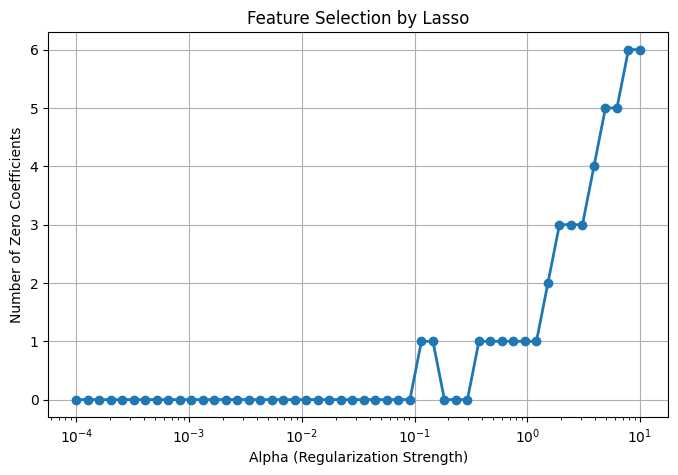

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

# Alpha values
alphas = np.logspace(-4, 1, 50)

zero_coefficients = []

for alpha in alphas:

    model = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    model.fit(X_train, y_train)

    zero_coefficients.append(
        np.sum(model.coef_ == 0)
    )

plt.figure(figsize=(8,5))

plt.plot(
    alphas,
    zero_coefficients,
    marker='o',
    linewidth=2
)

plt.xscale("log")

plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Number of Zero Coefficients")

plt.title("Feature Selection by Lasso")

plt.grid(True)

plt.show()

# Visualization 5 — Feature Importance (Coefficient Bar Chart)

This visualization shows **which features are important after training a Lasso model**.

Unlike the previous graph (Coefficient Path), which shows **how coefficients change** with different α values, this graph shows the **final coefficients** for **one chosen α**.

---

# Objective

After selecting an α (for example, α = 0.1), we want to answer:

> **Which features did Lasso keep?**

and

> **Which features did Lasso remove?**

---

# What is plotted?

### X-axis

```text
Feature Names
```

Example

```text
Age
Sex
BMI
BP
S1
S2
S3
S4
S5
S6
```

---

### Y-axis

```text
Coefficient Value
```

The height of each bar represents the learned coefficient.

Positive bar

↓

Positive relationship.

Negative bar

↓

Negative relationship.

Zero bar

↓

Feature removed.

---

# What should you observe?

Suppose the graph looks like

```text
BMI     █████████████

S5      ███████████████

BP      ███████

Age

Sex

S2

S4
```

Notice

Some bars have

```text
Height = 0
```

Those features have been completely removed.

---

# Positive coefficients

Example

```text
BMI = +25
```

Interpretation

As BMI increases,

the predicted diabetes progression increases.

---

# Negative coefficients

Example

```text
Sex = -12
```

Interpretation

Increasing this feature decreases the prediction.

(The exact interpretation depends on how the feature is encoded.)

---

# Zero coefficients

Example

```text
Age = 0
```

Interpretation

Lasso has completely ignored this feature.

Prediction becomes

```text
Prediction

=

...

+

0 × Age
```

Age has no contribution.

---

# Magnitude matters

Suppose

```text
BMI = 30

BP = 10
```

BMI influences prediction much more than BP.

Generally,

larger absolute coefficients

↓

greater influence on prediction.

---

# Key Takeaways

* Tall bars = Important features.
* Short bars = Less important features.
* Zero bars = Removed by Lasso.
* Positive bars increase predictions.
* Negative bars decrease predictions.

---
---

# Example Interpretation

Suppose the graph shows

```text
BMI      +25
BP       +15
S5       +32

Age      0
Sex      0
S2       0
```

Interpretation

* **BMI** is one of the most influential features.
* **S5** has the strongest positive impact.
* **BP** also contributes significantly.
* **Age**, **Sex**, and **S2** have been removed because their coefficients became zero.

This demonstrates Lasso's feature selection in a way that's easy to understand.

---

# Difference from the Previous Visualization

| Coefficient Path                   | Feature Importance                  |
| ---------------------------------- | ----------------------------------- |
| Trains many models (many α values) | Trains one model (single α)         |
| Shows how coefficients change      | Shows final coefficients            |
| Used to study regularization       | Used to identify important features |
| Multiple lines                     | One bar per feature                 |

---

# Conclusion

This visualization summarizes the final Lasso model. It tells us which features the model considers important, which features have a positive or negative effect on the prediction, and which features have been completely removed through L1 regularization.

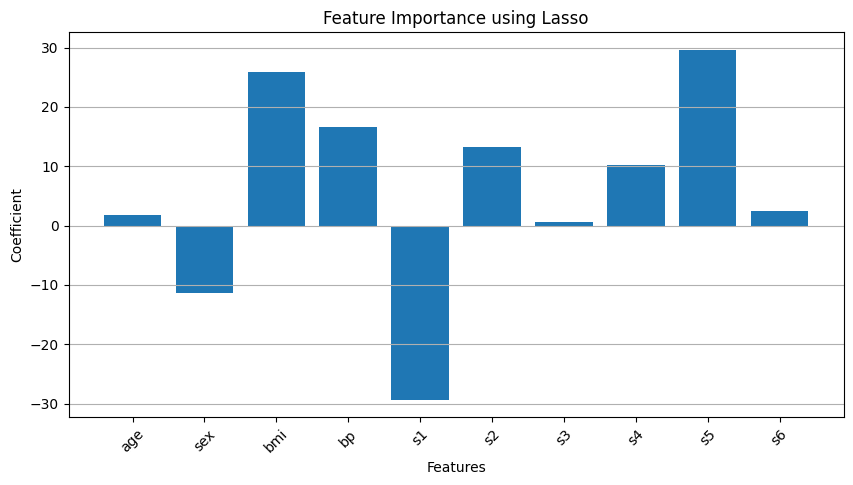

In [10]:
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt

# Train Lasso
model = Lasso(
    alpha=0.1,
    max_iter=10000
)

model.fit(X_train, y_train)

# Plot coefficients
plt.figure(figsize=(10,5))

plt.bar(
    X.columns,
    model.coef_
)

plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.title("Feature Importance using Lasso")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()